In [ ]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile('/online+retail.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/online_retail')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir('/content/online_retail'))

['Online Retail.xlsx']


In [ ]:
import glob

files = glob.glob('/content/online_retail/**/*', recursive=True)
print(files)

['/content/online_retail/Online Retail.xlsx']


In [ ]:
import pandas as pd
import glob

file = glob.glob('/content/online_retail/**/*', recursive=True)
file = [f for f in file if f.endswith('.xlsx')][0]

df = pd.read_excel(file)

print("Dataset loaded successfully!")
print(df.shape)
df.head()

Dataset loaded successfully!
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
customer_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

print(customer_frequency.describe())

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64


In [ ]:
import pandas as pd

# Date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate Total Amount if it doesn't already exist
if 'TotalAmount' not in df.columns:
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Reference date
reference_date = df['InvoiceDate'].max()

# RFM Analysis
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
)

print("RFM created successfully!")
rfm.head()

RFM created successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

print("RFM data standardized successfully!")

RFM data standardized successfully!


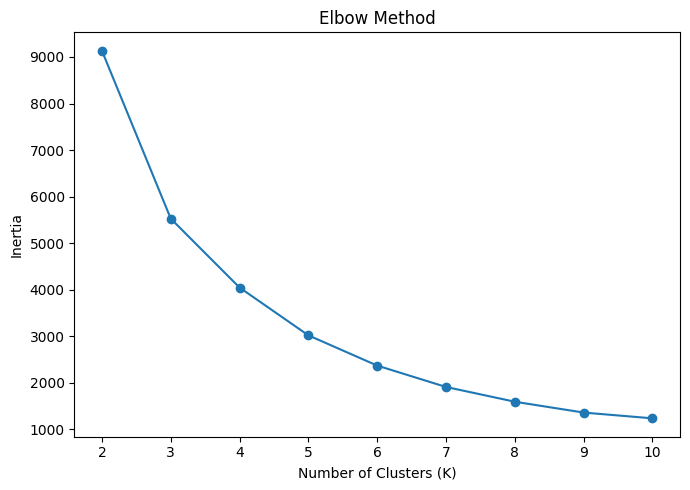

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Clustering completed!")
rfm.head()

Clustering completed!


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,2,0.00,1
12347.0,1,7,4310.00,0
12348.0,74,4,1797.24,0
12349.0,18,1,1757.55,0
12350.0,309,1,334.40,1


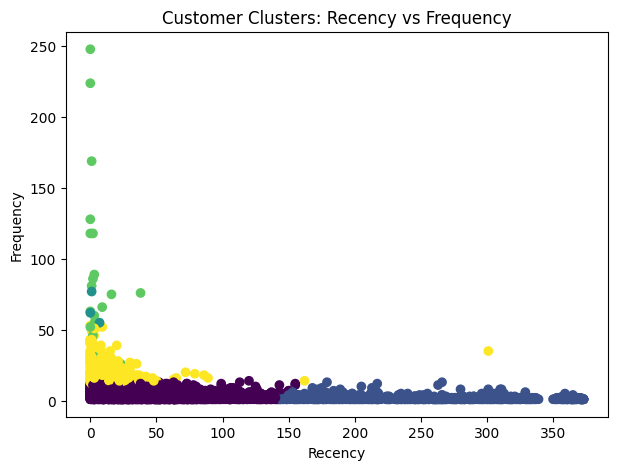

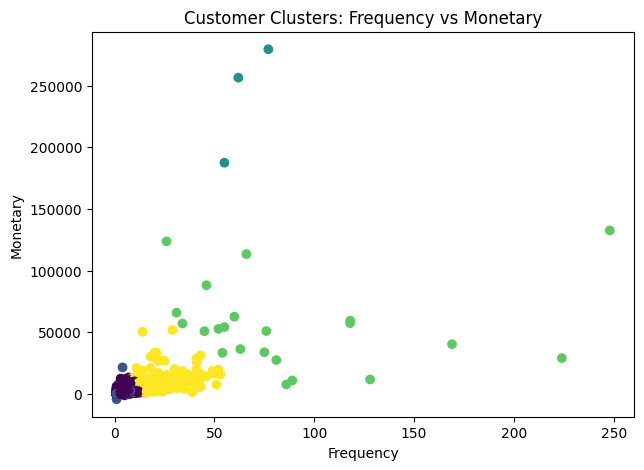

In [ ]:
import matplotlib.pyplot as plt

# Recency vs Frequency
plt.figure(figsize=(7, 5))
plt.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Cluster'])
plt.title('Customer Clusters: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.show()

# Frequency vs Monetary
plt.figure(figsize=(7, 5))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.title('Customer Clusters: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.189381,3.887048,1182.086153
1,248.507003,1.802988,453.748096
2,2.666667,64.666667,241136.560000
3,5.181818,88.363636,54540.575909
4,12.771160,20.774295,7508.998433


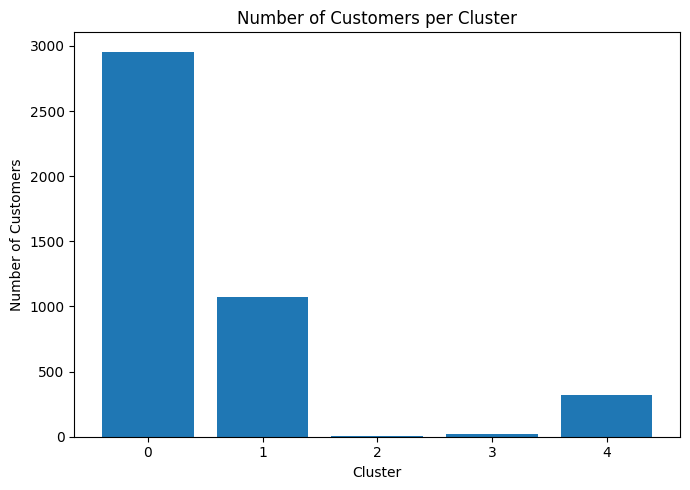

In [ ]:
# Cluster profile
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Cluster Profile:")
display(cluster_profile)

# Number of customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [ ]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster}:")

    if cluster_profile.loc[cluster, 'Recency'] < cluster_profile['Recency'].median():
        print("→ Recent customers: Target with loyalty offers and repeat-purchase campaigns.")

    if cluster_profile.loc[cluster, 'Frequency'] > cluster_profile['Frequency'].median():
        print("→ Frequent customers: Offer rewards, memberships, and exclusive deals.")

    if cluster_profile.loc[cluster, 'Monetary'] > cluster_profile['Monetary'].median():
        print("→ High-value customers: Provide premium offers and personalized promotions.")


Cluster 0:

Cluster 1:

Cluster 2:
→ Recent customers: Target with loyalty offers and repeat-purchase campaigns.
→ Frequent customers: Offer rewards, memberships, and exclusive deals.
→ High-value customers: Provide premium offers and personalized promotions.

Cluster 3:
→ Recent customers: Target with loyalty offers and repeat-purchase campaigns.
→ Frequent customers: Offer rewards, memberships, and exclusive deals.
→ High-value customers: Provide premium offers and personalized promotions.

Cluster 4:


In [ ]:
rfm.to_csv('customer_segments.csv', index=True)
print("Customer segmentation completed and saved!")

Customer segmentation completed and saved!
